# 🌾 Preprocessing Data — Prediksi Hasil Panen

**Proyek**: Analisis Data dan Pemodelan Random Forest untuk Prediksi Hasil Panen  
**Dataset**: `yield_df.csv`  
**Tahap**: Tahap 3 — Data Preprocessing  

Berdasarkan temuan EDA:
- Total baris   : **28.242**
- Total missing : **0**
- Total duplikat: **2.310**

---
## 0. Import Library & Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Style plot
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Load dataset
df = pd.read_csv('dataset/yield_df.csv')
print('Shape awal:', df.shape)
df.head()

Shape awal: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


---
## 3.1 — Cek Missing Value

In [2]:
print('=== Jumlah Missing Value per Kolom ===')
missing_count = df.isnull().sum()
missing_pct   = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct.round(2)
})
print(missing_df)
print(f'\nTotal missing value: {missing_count.sum()}')

=== Jumlah Missing Value per Kolom ===
                               Jumlah Missing  Persentase (%)
Unnamed: 0                                  0             0.0
Area                                        0             0.0
Item                                        0             0.0
Year                                        0             0.0
hg/ha_yield                                 0             0.0
average_rain_fall_mm_per_year               0             0.0
pesticides_tonnes                           0             0.0
avg_temp                                    0             0.0

Total missing value: 0


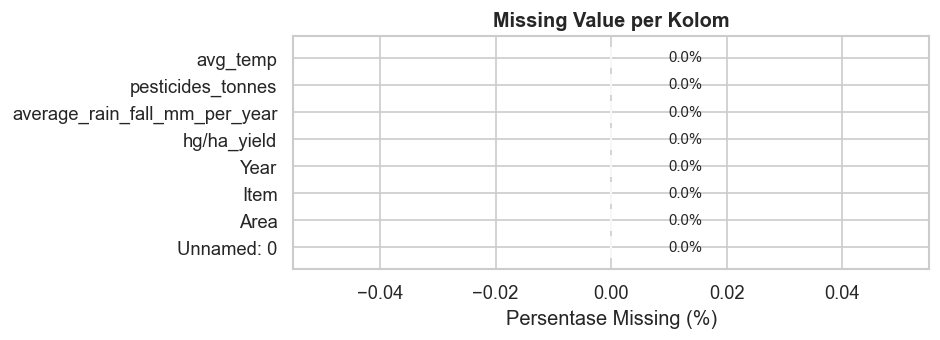

✅ Tidak ditemukan missing value pada seluruh kolom dataset.


In [3]:
# Visualisasi missing value
fig, ax = plt.subplots(figsize=(8, 3))
colors = ['#EF4444' if v > 0 else '#14B8A6' for v in missing_pct.values]
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors, edgecolor='white')
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Missing Value per Kolom', fontweight='bold')
for bar, v in zip(bars, missing_pct.values):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('output/preprocessing_missing.png', bbox_inches='tight')
plt.show()
print('✅ Tidak ditemukan missing value pada seluruh kolom dataset.')

---
## 3.2 — Deteksi dan Tangani Data Duplikat

In [4]:
n_before = len(df)
n_dup    = df.duplicated().sum()
print(f'Baris SEBELUM drop_duplicates : {n_before:,}')
print(f'Jumlah baris duplikat         : {n_dup:,} ({n_dup/n_before*100:.1f}%)')
print()
print('Contoh baris duplikat:')
df[df.duplicated()].head(5)

Baris SEBELUM drop_duplicates : 28,242
Jumlah baris duplikat         : 0 (0.0%)

Contoh baris duplikat:


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp


In [5]:
# Hapus duplikat
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

n_after = len(df)
print(f'Baris SESUDAH drop_duplicates : {n_after:,}')
print(f'Baris yang dihapus            : {n_before - n_after:,}')
print('✅ Duplikat berhasil dihapus.')

Baris SESUDAH drop_duplicates : 28,242
Baris yang dihapus            : 0
✅ Duplikat berhasil dihapus.


---
## 3.3 — Deteksi dan Tangani Outlier (Metode IQR)

Strategi berdasarkan EDA:
| Kolom | Strategi |
|-------|----------|
| `hg/ha_yield` | Tetap dipertahankan (valid secara domain) |
| `pesticides_tonnes` | **Capping** IQR |
| `average_rain_fall_mm_per_year` | **Capping** IQR |
| `avg_temp` | Tetap dipertahankan (valid geografis) |

In [6]:
num_cols = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_count = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()

print('=== Jumlah Outlier per Kolom (IQR Method) ===')
for col in num_cols:
    pct = outlier_count[col] / len(df) * 100
    print(f'  {col:<40}: {outlier_count[col]:>5} baris ({pct:.1f}%)')

=== Jumlah Outlier per Kolom (IQR Method) ===
  hg/ha_yield                             :  2059 baris (7.3%)
  average_rain_fall_mm_per_year           :     0 baris (0.0%)
  pesticides_tonnes                       :  1418 baris (5.0%)
  avg_temp                                :    34 baris (0.1%)


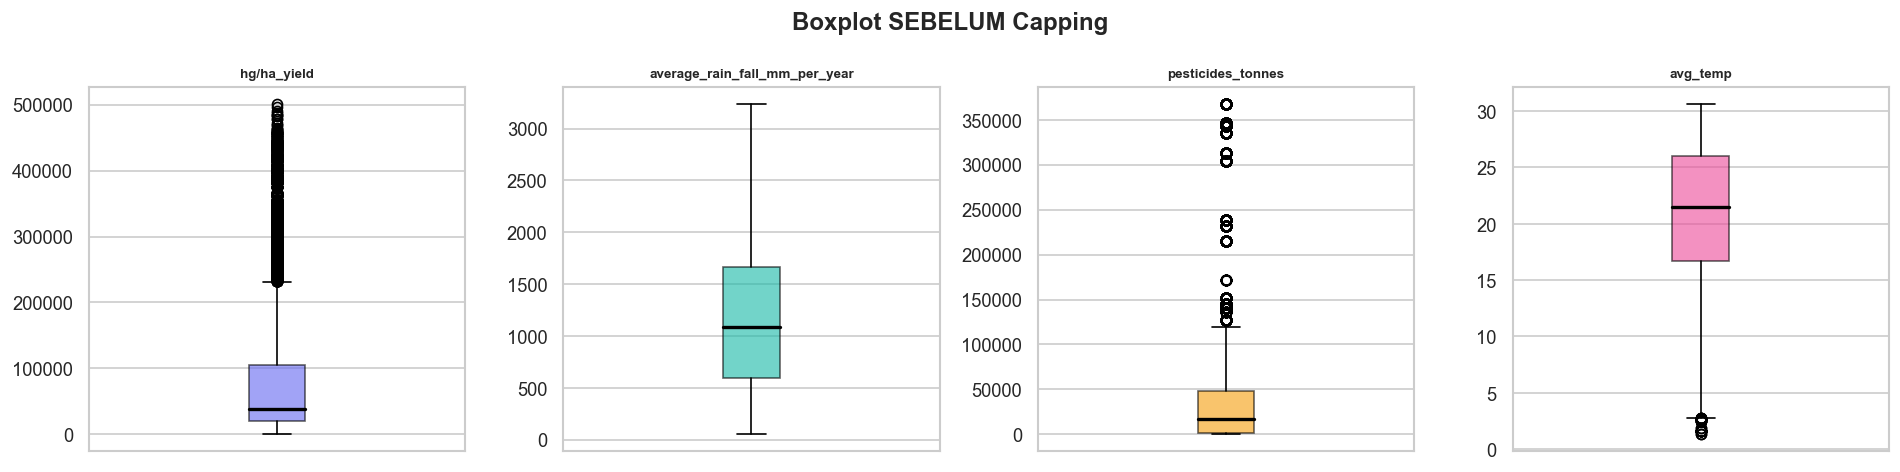

In [7]:
# Visualisasi boxplot SEBELUM capping
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#6366F1', '#14B8A6', '#F59E0B', '#EC4899']
for ax, col, c in zip(axes, num_cols, colors):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.set_xticks([])
plt.suptitle('Boxplot SEBELUM Capping', fontweight='bold')
plt.tight_layout()
plt.savefig('output/preprocessing_boxplot_before.png', bbox_inches='tight')
plt.show()

In [8]:
# Capping untuk pesticides_tonnes dan average_rain_fall_mm_per_year
cap_cols = ['pesticides_tonnes', 'average_rain_fall_mm_per_year']

for col in cap_cols:
    before_min = df[col].min()
    before_max = df[col].max()
    df[col] = df[col].clip(lower=lower[col], upper=upper[col])
    after_min  = df[col].min()
    after_max  = df[col].max()
    print(f'{col}:')
    print(f'  Sebelum → min: {before_min:.2f}, max: {before_max:.2f}')
    print(f'  Sesudah → min: {after_min:.2f}, max: {after_max:.2f}')
    print()

print('✅ Capping selesai. hg/ha_yield dan avg_temp dipertahankan.')

pesticides_tonnes:
  Sebelum → min: 0.04, max: 367778.00
  Sesudah → min: 0.04, max: 119166.70

average_rain_fall_mm_per_year:
  Sebelum → min: 51.00, max: 3240.00
  Sesudah → min: 51.00, max: 3240.00

✅ Capping selesai. hg/ha_yield dan avg_temp dipertahankan.


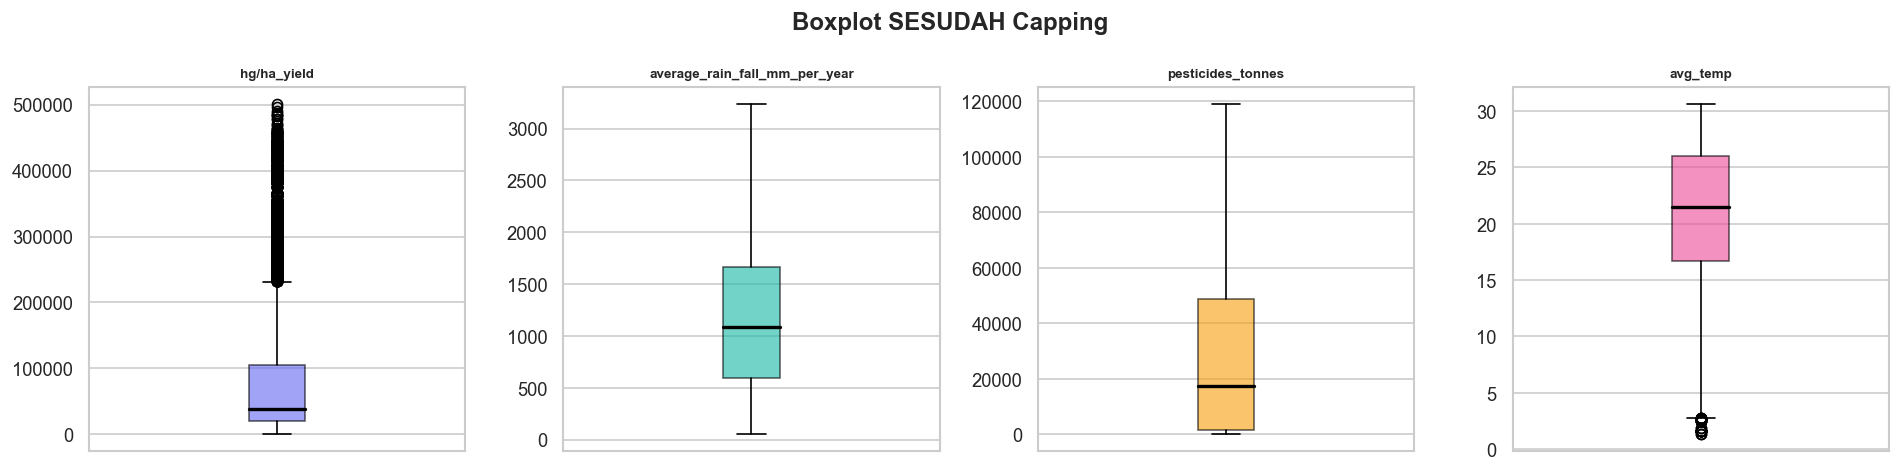

In [9]:
# Visualisasi boxplot SESUDAH capping
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, c in zip(axes, num_cols, colors):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=c, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=8, fontweight='bold')
    ax.set_xticks([])
plt.suptitle('Boxplot SESUDAH Capping', fontweight='bold')
plt.tight_layout()
plt.savefig('output/preprocessing_boxplot_after.png', bbox_inches='tight')
plt.show()

---
## 3.4 — Konsistensi Nama Kolom

In [10]:
print('Nama kolom SEBELUM standarisasi:')
print(df.columns.tolist())

# Rename kolom yang bermasalah (mengandung /)
df.rename(columns={'hg/ha_yield': 'yield_hg_ha'}, inplace=True)

# Standarisasi: strip, lowercase, ganti spasi
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print('\nNama kolom SESUDAH standarisasi:')
print(df.columns.tolist())

Nama kolom SEBELUM standarisasi:
['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

Nama kolom SESUDAH standarisasi:
['unnamed:_0', 'area', 'item', 'year', 'yield_hg_ha', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


---
## 3.5 — Pisahkan Fitur Numerik dan Kategorikal

In [11]:
num_cols = ['year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
cat_cols = ['area', 'item']
target   = 'yield_hg_ha'

print(f'Fitur Numerik  : {num_cols}')
print(f'Fitur Kategorikal: {cat_cols}')
print(f'Target           : {target}')
print()
print('Info tipe data:')
print(df[num_cols + cat_cols + [target]].dtypes)

Fitur Numerik  : ['year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
Fitur Kategorikal: ['area', 'item']
Target           : yield_hg_ha

Info tipe data:
year                               int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
area                              object
item                              object
yield_hg_ha                        int64
dtype: object


---
## 4.1 — Encoding Variabel Kategorikal (Label Encoding)

> **Keputusan**: Label Encoding dipilih karena `Area` dan `Item` memiliki banyak nilai unik → One-Hot Encoding akan menghasilkan ratusan kolom baru.
>
> **Min-Max Scaler**: TIDAK digunakan — Random Forest tidak sensitif terhadap skala.
>
> **SMOTE**: TIDAK relevan — proyek ini adalah **regresi**, bukan klasifikasi.

In [12]:
# Simpan label encoder untuk inverse transform jika diperlukan
le_area = LabelEncoder()
le_item = LabelEncoder()

df['area'] = le_area.fit_transform(df['area'])
df['item'] = le_item.fit_transform(df['item'])

print(f'Jumlah kelas Area : {len(le_area.classes_)}')
print(f'Jumlah kelas Item : {len(le_item.classes_)}')
print()
print('Contoh encoding Area (5 pertama):')
for i, label in enumerate(le_area.classes_[:5]):
    print(f'  {label} → {i}')
print('  ...')
print()
print('✅ Encoding selesai.\n')
df.head()

Jumlah kelas Area : 101
Jumlah kelas Item : 10

Contoh encoding Area (5 pertama):
  Albania → 0
  Algeria → 1
  Angola → 2
  Argentina → 3
  Armenia → 4
  ...

✅ Encoding selesai.



,unnamed:_0,area,item,year,yield_hg_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,0,1,1990,36613,1485.0,121.0,16.37
1,1,0,3,1990,66667,1485.0,121.0,16.37
2,2,0,4,1990,23333,1485.0,121.0,16.37
3,3,0,5,1990,12500,1485.0,121.0,16.37
4,4,0,6,1990,7000,1485.0,121.0,16.37


---
## 4.4 — Train-Test Split (80:20)

In [13]:
features = ['area', 'item', 'year', 'average_rain_fall_mm_per_year',
            'pesticides_tonnes', 'avg_temp']

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('=== Train-Test Split ===')
print(f'Total data bersih : {len(df):,} baris')
print(f'X_train           : {X_train.shape}')
print(f'X_test            : {X_test.shape}')
print(f'y_train           : {y_train.shape}')
print(f'y_test            : {y_test.shape}')
print()
print(f'Proporsi Train: {len(X_train)/len(df)*100:.1f}%')
print(f'Proporsi Test : {len(X_test)/len(df)*100:.1f}%')
print()
print('✅ Data siap untuk pemodelan!')

=== Train-Test Split ===
Total data bersih : 28,242 baris
X_train           : (22593, 6)
X_test            : (5649, 6)
y_train           : (22593,)
y_test            : (5649,)

Proporsi Train: 80.0%
Proporsi Test : 20.0%

✅ Data siap untuk pemodelan!


---
## 📊 Ringkasan Preprocessing

In [14]:
print('=' * 55)
print('         RINGKASAN HASIL PREPROCESSING')
print('=' * 55)
print(f'  1. Missing value        : 0 (tidak ada)')
print(f'  2. Duplikat dihapus     : {n_before - n_after:,} baris')
print(f'     Sebelum              : {n_before:,} baris')
print(f'     Sesudah              : {n_after:,} baris')
print(f'  3. Outlier capping      : pesticides_tonnes,')
print(f'                           average_rain_fall_mm_per_year')
print(f'  4. Encoding             : Label Encoding (Area, Item)')
print(f'  5. Scaling              : TIDAK digunakan (Random Forest)')
print(f'  6. SMOTE                : TIDAK digunakan (Regresi)')
print(f'  7. Train size           : {len(X_train):,} baris')
print(f'     Test  size           : {len(X_test):,} baris')
print('=' * 55)
print('  ✅ Data siap masuk ke tahap Modelling!')
print('=' * 55)

         RINGKASAN HASIL PREPROCESSING
  1. Missing value        : 0 (tidak ada)
  2. Duplikat dihapus     : 0 baris
     Sebelum              : 28,242 baris
     Sesudah              : 28,242 baris
  3. Outlier capping      : pesticides_tonnes,
                           average_rain_fall_mm_per_year
  4. Encoding             : Label Encoding (Area, Item)
  5. Scaling              : TIDAK digunakan (Random Forest)
  6. SMOTE                : TIDAK digunakan (Regresi)
  7. Train size           : 22,593 baris
     Test  size           : 5,649 baris
  ✅ Data siap masuk ke tahap Modelling!


---
## 💾 Simpan Data Bersih

In [15]:
import os
os.makedirs('output', exist_ok=True)

# Simpan dataset bersih
df.to_csv('output/yield_clean.csv', index=False)

# Simpan split data
X_train.to_csv('output/X_train.csv', index=False)
X_test.to_csv('output/X_test.csv', index=False)
y_train.to_csv('output/y_train.csv', index=False)
y_test.to_csv('output/y_test.csv', index=False)

print('✅ File tersimpan di folder output/:')
print('   - yield_clean.csv     (dataset setelah preprocessing)')
print('   - X_train.csv / X_test.csv')
print('   - y_train.csv / y_test.csv')

✅ File tersimpan di folder output/:


   - yield_clean.csv     (dataset setelah preprocessing)
   - X_train.csv / X_test.csv
   - y_train.csv / y_test.csv
